### 1. Question and Answer (Q&A) System
### Introduction
>   Question and Answer (QA) systems have attracted significant attention in recent years due to their ability to automatically extract answers from text. These systems play a key role in various fields such as information retrieval, customer support, and virtual assistants.
>   
>   The goal of this exercise is to design and implement an extractive question answering system based on transformers that receives a text and a related question, and extracts the best appropriate answer from the text. Unlike generative QA systems that produce answers from scratch, extractive QA systems rely on information present in the context text to generate answers (as shown in Figure 1). Using the power of deep learning and pre-trained language models like BERT, these systems can effectively understand complex language structures, textual relationships, and semantic differences necessary for accurate answer extraction.
>   
```
Question: The New York Giants and the New York Jets play
at which stadium in NYC ?
Context: The city is represented in the National Football
League by the New York Giants and the New York Jets,
although both teams play their home games at MetLife
Stadium in nearby East Rutherford, New Jersey, which
hosted Super Bowl XLVIII in 2014.
```
>   Sample question and text pair with the answer marked in the text, taken from the SQuAD dataset
>   
>   In this exercise, you will enter the world of question and answer systems in Persian language by designing and implementing a BERT model on the PQuad dataset. This exercise includes data preprocessing, model design, exception management, and performance evaluation using Exact Match (EM) and F1 score metrics.
### 1-1. Paper Introduction (10 points)
>   To understand the functionality of the BERT transformer model, read the original BERT paper (Devlin et al., 2018) from [this link](https://aclanthology.org/N19-1423/) to understand the architecture, tasks, and objective functions on which BERT was pretrained. Explain the key components of the BERT model, including its transformer architecture, input representation, and pre-training objectives.
### 1-2. Data Preprocessing (30 points)
>   The dataset used in this exercise is the PQuad dataset, which is accessible through [this link](https://github.com/AUT-NLP/PQuAD). First, you need to display statistical information including number, type, and length of texts and questions of the dataset after placing them in a dataframe. This helps you ensure data quality and identify any illogical or missing data.
>   
>   Then implement the necessary preprocessing including Tokenization and Embedding of data for the task at hand.
#### 1-2-1. Tokenization

>   BERT uses tokens for text processing. This means that long texts are divided into smaller units called tokens. These tokens typically include words, symbols, and even parts of words. For BERT tokenization, you can use the specialized BERT tokenizer provided by libraries such as transformers. This tokenizer automatically converts inputs to BERT tokens. This tokenizer also simultaneously performs operations like Padding and Truncation to make the input size appropriate for the model.
#### 1-2-2. Embedding

>   Embeddings are processes that convert tokens into numerical vectors. These vectors represent the semantic and grammatical features of words and sentences. In BERT models, each word or token is converted into a numerical vector in the embedding space that represents the features of that word.
>   
>   BERT uses its own embeddings for each token, which include three main types:
>   
>   - Token Embeddings: which assigns a vector to each token.
>   - Segment Embeddings: to show the difference between two sections (text and question).
>   - Position Embeddings: to represent the position of each token in the text (i.e., first, second tokens...).
>   
>   These embeddings are used together in the BERT model for processing data and producing results. During tokenization, tokens are numerically input into the model. These tokens are then converted to numerical embeddings that include semantic information about each word and its position in the sentence.
#### 1-2-3. Input Management

>   For the BERT model, inputs must be divided into two main parts:
>   1. Question text: which must be input to the model.
>   2. Context text: which contains the text from which the model must extract the answer.
>   
>   In extractive models, the question and context text must be connected so that the model can find the best answer. This is usually done using a combination of question and context tokens.
>   
>   During preprocessing, the question and context text must be converted into a single token. The BERT model specifically uses separator tokens to separate the question from the context text.

#### 1-2-4. Creating Attention Mask

>   Attention mask is another important component in data processing that tells the model which parts of the inputs should be processed and which parts should be ignored. This mask is typically used for data with different lengths. Usually, BERT models use attention masks to prevent processing padding tokens.
#### 1-2-5. Batching

>   After completing all preprocessing steps, data must be divided into batches so that the model can process them simultaneously. This helps increase efficiency and typically uses a DataLoader in PyTorch or similar for this purpose.
>   
>   For train, validation, and test, use the data with the same names in the dataset.
#### 1-3. Model Implementation (50 points)

>   The general structure of a question and answer system includes inputs such as user questions and reference texts, which allow the model to extract relevant information. In this dataset, we have text, question, and answer. Outputs typically include generated answers and their validity score based on the answers we have.
>   
>   Models used typically include natural language processing models like BERT designed to understand text and identify relationships between questions and answers. Error functions like Cross-Entropy Loss and Mean Squared Error are used to train the model to learn question understanding, correct information extraction, and logical answer generation. Finally, the model's goal is to improve its ability to identify and produce accurate and relevant answers to questions.
>   
>   For implementation, use two models based on ParsBERT and ALBERT. Their pre-trained models are accessible on Huggingface from [this link](https://huggingface.co/HooshvareLab/bert-base-parsbert-uncased) and [this link](https://huggingface.co/m3hrdadfi/albert-fa-base-v2). ParsBERT has the same BERT model structure that has been trained on Persian texts. ALBERT is a transformer-based model built on the BERT architecture (a transformer-based model that uses bidirectional attention to analyze and contextually understand texts) and its pre-trained model on Persian data is accessible.
>   
>   Implement the designed network using one of these two models. Note that using the AutoModelForQuestionAnswering class is not permitted.
#### 1-4. Evaluation and Post-processing (20 points)

>   During the task execution by the model, exceptions occur during data loading, preprocessing, and post-processing due to the length of context texts and the input limitations of transformer models, which need to be managed. Ensure that your model can handle these exceptions and report them.
>   
>   After managing exceptions, evaluate your two trained models on the test dataset using two metrics, EM and F1-score, and compare your results with those mentioned in the paper. You can use ready-made tools for evaluation.

### Answer

#### The Transformer Architecture

BERT (Bidirectional Encoder Representations from Transformers) is built on an **encoder-only** transformer architecture. Unlike models that use encoder-decoder structures, BERT focuses exclusively on understanding and representing input sequences, making it well-suited for tasks like text classification, question answering, and language understanding.

The core innovation of BERT's transformer architecture lies in its self-attention mechanism:

- **Self-Attention**: Instead of processing words in sequence, each word in a sentence can directly **attend** to every other word, determining how much focus to place on each one when constructing its representation. This creates rich contextual embeddings.

- **Bidirectional Self-Attention**: Unlike unidirectional models like GPT, BERT's self-attention is bidirectional, allowing it to look both left and right with respect to any given token. This bidirectionality is crucial for BERT's understanding of context.

- **Multi-Head Attention**: BERT doesn't just use a single attention mechanism but employs multiple "heads" of attention. Each head can focus on different aspects of the relationships between words. For example, one head might focus on syntactic relationships while another captures semantic connections.

- **Layer Structure**: BERT stacks multiple transformer encoder blocks. Each block contains:
  * Multi-head self-attention layer
  * Feed-forward neural network
  * Layer normalization components
  * Residual connections (which help with gradient flow during training)

BERT's encoder stack has two main architectural parameters: L (the number of layers) and H (the hidden size). The BERT-base variant uses 12 such layers with 12 attention heads and 768 hidden dimensions, while BERT-large has 24 layers with 16 attention heads and 1024 hidden dimensions (340M parameters).

Unlike decoder models that generate output sequences autoregressively (one token at a time), BERT's encoder-only architecture processes all tokens simultaneously without causal masking. This design allows BERT to create deep contextual representations of text rather than to generate new text.

#### Input Representation

BERT combines three different types of information for each token:

1. **Token Embeddings**: These capture the semantic meaning of individual words or subwords. BERT uses WordPiece tokenization, breaking uncommon words into subword units. For example, "unaffordable" might become "un" + "afford" + "able".

2. **Position Embeddings**: Since transformers process all tokens in parallel, they lose the sequential information that RNNs naturally preserve. Position embeddings restore this information by explicitly encoding each token's position in the sequence. Unlike some other models that use sinusoidal functions, BERT uses learned position embeddings.

3. **Segment Embeddings**: These identify which segment of text a token belongs to. This is crucial for tasks like question answering or natural language inference. Tokens from the first sentence receive one segment embedding, while tokens from the second sentence receive another.

These three embeddings are summed element-wise to create the final representation for each token before feeding to the transformer layers.

#### Special Tokens and Their Functions

BERT employs several special tokens for different purposes:

- **[CLS]** (Classification Token): Always placed at the beginning of each input sequence. The final hidden state of this token is used as the aggregate sequence representation for classification tasks. It learns to capture the overall essence of the entire input.

- **[SEP]** (Separator Token): Used to separate different segments within an input sequence. For example, in a question-answering task, it separates the question from the context paragraph.

- **[MASK]** (Mask Token): Used as a placeholder during pre-training to replace tokens that the model needs to predict.

- **[PAD]** (Padding Token): Used to make all input sequences the same length within a batch, as required by the model architecture.

#### Pre-training Objectives

##### **Masked Language Modeling (MLM)**

MLM is an approach to bidirectional training:

1. The model takes a sentence and randomly masks 15% of the tokens.
2. Of these masked tokens:
   - 80% are replaced with the actual [MASK] token
   - 10% are replaced with a random token from the vocabulary
   - 10% are left unchanged

This variation prevents the model from simply memorizing which tokens were masked and forces it to maintain a strong representation for every input token.

The model's objective is to predict the original tokens at the masked positions based on its context. This requires understanding both the preceding and following context, leading to bidirectional learning.

##### **Next Sentence Prediction (NSP)**

While MLM focuses on word-level understanding, NSP targets sentence-level relationships:

1. The model is given pairs of sentences and must predict whether the second sentence actually follows the first in the original text.
2. During training, 50% of the pairs are consecutive sentences (labeled as "IsNext"), and 50% are random non-consecutive sentences (labeled as "NotNext").

This task helps BERT learn relationships between sentences, and learning cross-sentence reasoning.

In [1]:
# ----- Imports & Global Configuration -----

import os, re, json, collections, requests, warnings
from typing import Dict, List, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import Dataset
from tqdm.auto import tqdm
import evaluate

warnings.filterwarnings("ignore", category=UserWarning) # Suppress common UserWarnings
plt.style.use("seaborn-v0_8-darkgrid")        # unified plot style across the file

class CFG:
    """Central place for every hyper-parameter and path."""
    PRETRAINED = {
        "ParsBERT": "HooshvareLab/bert-base-parsbert-uncased",
        "ALBERT":   "m3hrdadfi/albert-fa-base-v2",
    }

    # ---- dataset ----
    # 1. Renamed RAW_URL to DATA_URL for clarity with its usage in load_pquad.
    # 2. Set DATA_URL to the non-raw GitHub URL. The _download function will handle conversion.
    #    The AUT-NLP/PQuAD repository uses 'master' as its default branch.
    DATA_URL   = "https://github.com/AUT-NLP/PQuAD/master/Dataset/"
    
    # 3. Renamed FILES to DATA_FILES to match usage in load_pquad.
    DATA_FILES = {"train": "Train.json", "validation": "Validation.json", "test": "Test.json"}
    
    # 4. Added DATA_DIRECTORY for storing downloaded files.
    #    It's placed inside OUT_DIR for organization.
    OUT_DIR    = "./qa_run"  # everything under this folder (also used for model outputs, plots)
    DATA_DIRECTORY = os.path.join(OUT_DIR, "data_cache")


    # ---- sequence lengths ----
    MAX_LEN    = 256           # max tokens per window
    STRIDE     = 96            # overlap tokens between windows

    # ---- trainer ----
    TR_BS      = 4             # physical batch per step
    EV_BS      = 32
    EPOCHS     = 2
    GA_STEPS   = 8             # grad accumulation -> eff-batch = TR_BS × GA_STEPS
    LR         = 3e-5
    WARMUP     = 0.10          # fraction of total steps for warmup
    MAX_GNORM  = 1.0           # gradient clipping
    DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED       = 42

    # ---- output & misc ---- (OUT_DIR is defined above with DATA_DIRECTORY)
    PLOT_DIR   = os.path.join(OUT_DIR, "plots") # For saving plots


# make directory and fix random seeds for reproducibility
os.makedirs(CFG.OUT_DIR, exist_ok=True)
os.makedirs(CFG.PLOT_DIR, exist_ok=True) # Create plot directory
os.makedirs(CFG.DATA_DIRECTORY, exist_ok=True) # Create data cache directory

In [2]:
# Set seeds
if hasattr(torch, 'manual_seed'):
    torch.manual_seed(CFG.SEED)
if hasattr(np, 'random') and hasattr(np.random, 'seed'):
    np.random.seed(CFG.SEED)

In [3]:
# ------------------------------------#
# 1 ─ Persian Text Normaliser         #
# ------------------------------------#
class FaNorm:
    """Fast, minimal Persian/Arabic normalisation."""
    _dia = dict.fromkeys([chr(c) for c in range(0x064B, 0x065F + 1)] + ["\u0670"], "")
    _map = str.maketrans({
        # unify common Arabic variants to Persian equivalents
        "أ": "ا", "إ": "ا", "آ": "ا", "ٱ": "ا",
        "ي": "ی", "ى": "ی", "ك": "ک",
        "ة": "ه", "ؤ": "و", "ئ": "ی"
    })
    # Keeps: Persian/Arabic, ZWNJ, numbers, basic Latin, common punctuation & symbols.
    _non = re.compile(r"[^\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\w\s\.\?\!،؛٪﷼$€£¥₩\+\-\*\/\=\<\>\(\)\[\]\{\}\u200C\u200D\'\"‘’“”]+")


    @staticmethod
    def clean(text: str) -> str:
        """Apply character map ->drop diacritics ->strip noise ->tidy spaces."""
        if not isinstance(text, str): return "" # Handle non-string inputs
        text = text.translate(FaNorm._map)
        text = text.translate(FaNorm._dia)
        text = FaNorm._non.sub("", text) # Remove unwanted characters
        return re.sub(r"\s+", " ", text).strip() # Normalize whitespace


# ----- Download + Parse PQuAD -----
def _download(file_url: str, local_path: str):
    """
    Downloads a file, intelligently handling GitHub URLs to fetch raw content.
    """
    download_url = file_url
    # Transform GitHub URL to raw content URL if necessary
    if "github.com" in file_url and "raw.githubusercontent.com" not in file_url:
        download_url = file_url.replace("github.com", "raw.githubusercontent.com")
        # Remove '/blob/' segment if present, common in URLs copied from browser viewing file
        download_url = download_url.replace("/blob/", "/") 
    
    print(f"Attempting to download from: {download_url}")
    try:
        response = requests.get(download_url, timeout=60) # Increased timeout
        response.raise_for_status()  # Raise an HTTPError for bad responses 
        
        # Ensure the directory for the local_path exists before writing
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        
        with open(local_path, "w", encoding="utf-8") as f:
            f.write(response.text)
        print(f"Successfully downloaded and saved to {local_path}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {download_url}: {e}")
        raise # Re-raise the exception to halt execution if download is critical

def extract_qa_pairs(json_data_articles: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Extracts and normalizes question-answer pairs from SQuAD-like JSON data.
    """
    qa_pairs_list: List[Dict[str, Any]] = []
    for article in tqdm(json_data_articles, desc="Articles processed"):
        normalized_title = FaNorm.clean(article["title"]) # Normalize title
        for paragraph in article["paragraphs"]:
            context_text = FaNorm.clean(paragraph["context"])
            for qa_pair in paragraph["qas"]:
                answer_texts_raw = qa_pair.get("answers", [])
                answer_texts_normalized = [FaNorm.clean(ans["text"]) for ans in answer_texts_raw]
                # Filter out any empty strings that might result from normalization of empty original answers
                answer_texts_filtered = [ans_txt for ans_txt in answer_texts_normalized if ans_txt]

                answer_starts = []
                valid_answer_texts = []
                raw_context  = paragraph["context"]
                raw_question = qa_pair["question"]

                if answer_texts_filtered:
                    for txt in answer_texts_filtered:
                        start_idx = context_text.find(txt) # Find normalized answer in normalized context
                        if start_idx != -1:
                            answer_starts.append(start_idx)
                            valid_answer_texts.append(txt)
                
                # Handle cases where no valid answer is found or answers were originally empty
                if not valid_answer_texts:
                    valid_answer_texts = [""] # SQuAD format expects non-empty list for "text"
                    answer_starts = [-1]      # Use -1 as an "unanswerable" signal for training processing

                qa_pairs_list.append({
                    "id": str(qa_pair["id"]),
                    "title":normalized_title,
                    "raw_context": paragraph["context"],
                    "raw_question": qa_pair["question"],
                    "context": context_text,
                    "question": FaNorm.clean(qa_pair["question"]),
                    "answers": {"text": valid_answer_texts, "answer_start": answer_starts},
                })
    return qa_pairs_list

 # Main Data Loading Function
def load_pquad() -> Dict[str, Dict[str, Any]]:
    """
    Load and process the complete PQuAD dataset (Train, Validation, Test).
    Returns a dictionary split_name -> {'df': DataFrame, 'hf': HuggingFace Dataset}.
    """
    loaded_datasets = {}
    
    for split_name, filename in CFG.DATA_FILES.items():
        print(f"\nProcessing '{split_name}' split (file: {filename})...")
        # Path where the raw JSON file will be saved/loaded from
        file_path = os.path.join(CFG.DATA_DIRECTORY, filename)
        
        # Download the file if it doesn't already exist locally
        if not os.path.exists(file_path):
            file_url = CFG.DATA_URL + filename # Construct full URL
            print(f"Downloading {split_name} dataset from {file_url}...")
            _download(file_url, file_path)
        else:
            print(f"Found existing file for {split_name} at {file_path}. Skipping download.")
        
        # Load and parse the JSON data from the file
        print(f"Loading JSON data for {split_name} from {file_path}...")
        try:
            with open(file_path, 'r', encoding='utf-8') as json_file:
                # The PQuAD JSON structure has a top-level 'data' key
                json_data_articles = json.load(json_file)['data']
        except FileNotFoundError:
            print(f"ERROR: File not found at {file_path}. Please check the download or path.")
            raise

        # Extract question-answer pairs into a list of dictionaries
        qa_pairs = extract_qa_pairs(json_data_articles)
        
        # Create a Pandas DataFrame
        if not qa_pairs:
            print(f"Warning: No QA pairs extracted for {split_name} split. Resulting DataFrame will be empty.")
            # Create an empty DataFrame with the expected schema to prevent downstream errors
            dataframe = pd.DataFrame(columns=["id", "title", "context", "question", "answers"])
        else:
            dataframe = pd.DataFrame(qa_pairs)
            # Ensure 'id' column is string type, important for HuggingFace Dataset conversion
            if 'id' in dataframe.columns:
                dataframe['id'] = dataframe['id'].astype(str)
        
        # Store both the DataFrame and its HuggingFace Dataset version
        loaded_datasets[split_name] = {
            "df": dataframe,
            "hf": Dataset.from_pandas(dataframe) # Requires 'datasets' library
        }
        
        print(f"'{split_name}' dataset loaded and processed: {len(dataframe)} examples found.")
    
    print("\nAll PQuAD dataset splits have been processed.")
    return loaded_datasets

def display_normalization(all_dataset_splits):
    """Displays statistics and examples of text normalization."""
    print("\n--- Text Normalization Statistics and Examples ---")
    for split_name, data_bundle in all_dataset_splits.items():
        df = data_bundle["df"]
        if df.empty:
            print(f"\n{split_name.capitalize()} Split is empty. Skipping normalization examples and stats.")
            continue

        print(f"\n{split_name.capitalize()} Split:")
        # Example before and after normalization
        print("\nExamples before and after normalization:")
        for i in range(min(5, len(df))):  # Display first 5 examples
            original_context = df["raw_context"].iloc[i]
            normalized_context = df["context"].iloc[i]
            original_question = df["raw_question"].iloc[i]
            normalized_question = df["question"].iloc[i]
            print(f"\nExample {i + 1}:")
            print(f"  Original Context: {original_context[:200]}...")  # Display only first 100 chars
            print(f"  Normalized Context: {normalized_context[:200]}...")
            print(f"  Original Question: {original_question[:200]}...")
            print(f"  Normalized Question: {normalized_question[:200]}...")

        # Calculate normalization stats (example: number of characters removed)
        original_context_lengths = df["raw_context"].str.len()
        normalized_context_lengths = df["context"].str.len()
        chars_removed_context = original_context_lengths.sum() - normalized_context_lengths.sum()
        
        original_question_lengths = df["raw_question"].str.len()
        normalized_question_lengths = df["question"].str.len()
        chars_removed_question = original_question_lengths.sum() - normalized_question_lengths.sum()

        print("\nNormalization Statistics:")
        print(f"  Total characters removed from context: {chars_removed_context}")
        print(f"  Total characters removed from questions: {chars_removed_question}")

def display_qa_pair_examples(all_dataset_splits):
    """Displays examples of extracted question-answer pairs."""
    print("\n--- Question-Answer Pair Examples ---")
    for split_name, data_bundle in all_dataset_splits.items():
         df = data_bundle["df"]
         if df.empty:
            print(f"\n{split_name.capitalize()} Split is empty. Skipping QA pair examples.")
            continue
         print(f"\n{split_name.capitalize()} Split:")
         for i in range(min(5, len(df))):  # Display first 5 examples
            qa_pair = df.iloc[i]
            print(f"\nExample {i + 1}:")
            print(f"  Context: {qa_pair['context'][:200]}...") 
            print(f"  Question: {qa_pair['question']}")
            print(f"  Answer(s): {qa_pair['answers']['text']}")


In [4]:
# ----- Quick Descriptive Statistics -----

class Explorer: 
    """Tiny EDA helper - prints summary + histograms for basic length analysis."""
    def __init__(self, dataset_splits: Dict[str, Dict[str, Any]]):
        self.dataset_splits = dataset_splits

    @staticmethod
    def _calculate_series_stats(series: pd.Series) -> Dict[str, float]:
        if series.empty:
            return {"mean": 0.0, "median": 0.0, "min": 0.0, "max": 0.0, "std_dev": 0.0}
        return {
            "mean": float(series.mean()), "median": float(series.median()),
            "min": float(series.min()), "max": float(series.max()), "std_dev": float(series.std())
        }

    def analyse(self) -> Dict[str, Any]:
        all_stats: Dict[str, Any] = {}
        print("\n--- Dataset Quick Analysis (Length Statistics) ---")
        for split_name, data_bundle in self.dataset_splits.items():
            df = data_bundle["df"]
            if df.empty:
                print(f"\n{split_name.capitalize()} Split is empty. Skipping analysis.")
                all_stats[split_name] = {"total_examples": 0}
                continue

            context_lengths = df["context"].str.len()
            question_lengths = df["question"].str.len()
            
            # Check for answers and their structure before attempting to access ans["answer_start"][0]
            # Robust check for unanswerable: if 'answers' is empty, or 'answer_start' is empty, or first start is -1
            unanswerable_count = 0
            if "answers" in df.columns:
                unanswerable_count = int(df["answers"].apply(
                    lambda ans: not ans or not ans.get("answer_start") or ans["answer_start"][0] == -1
                ).sum())

            split_summary = {
                "total_examples": len(df),
                "context_length_stats":  self._calculate_series_stats(context_lengths),
                "question_length_stats": self._calculate_series_stats(question_lengths),
                "unanswerable_questions":  unanswerable_count
            }
            all_stats[split_name] = split_summary

            print(f"\n{split_name.capitalize()} Split:")
            print(f"  Total Examples: {split_summary['total_examples']}")
            print(f"  Context Length (chars): Mean={split_summary['context_length_stats']['mean']:g}, Median={split_summary['context_length_stats']['median']:g}")
            print(f"  Question Length (chars): Mean={split_summary['question_length_stats']['mean']:g}, Median={split_summary['question_length_stats']['median']:g}")
            print(f"  Unanswerable (or no valid answer found): {split_summary['unanswerable_questions']}")

            if not context_lengths.empty:
                plt.figure(figsize=(9, 4))
                plt.hist(context_lengths.dropna(), bins=60, edgecolor="black", color="steelblue", alpha=0.7)
                plt.title(f"{split_name.capitalize()} · Context Length (chars)")
                plt.xlabel("Context Length (characters)"); plt.ylabel("Frequency")
                plt.tight_layout()
                plt.show()
                plt.close()
        return all_stats


# ------------------------------------#
# 4 ─ Tokenisation Helpers            #
# ------------------------------------#
def encode_train_examples(examples: Dict[str, Any], tokenizer: AutoTokenizer) -> Dict[str, Any]:
    questions = examples["question"]
    contexts = examples["context"]

    tokenized_output = tokenizer(
        questions, contexts,
        max_length=CFG.MAX_LEN, stride=CFG.STRIDE,
        truncation="only_second", padding="max_length",
        return_overflowing_tokens=True, return_offsets_mapping=True,
    )

    sample_mapping = tokenized_output.pop("overflow_to_sample_mapping")
    offset_mappings_batch = tokenized_output.pop("offset_mapping")

    start_token_positions, end_token_positions = [], []

    for i, feature_offset_mapping in enumerate(offset_mappings_batch):
        original_example_index = sample_mapping[i]
        ans_dict = examples["answers"][original_example_index]
        
        # Use the first valid answer for training
        answer_char_start = -1
        answer_text = ""
        if ans_dict.get("answer_start") and ans_dict.get("text"):
            for ans_idx in range(len(ans_dict["answer_start"])):
                if ans_dict["answer_start"][ans_idx] != -1 and ans_dict["text"][ans_idx]:
                    answer_char_start = ans_dict["answer_start"][ans_idx]
                    answer_text = ans_dict["text"][ans_idx]
                    break
        
        answer_char_end = answer_char_start + len(answer_text) if answer_char_start != -1 else -1

        sequence_ids = tokenized_output.sequence_ids(i)
        
        # Find context span robustly
        context_token_start_index = sequence_ids.index(1)
        context_token_end_index   = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        # Default to CLS token (0) for unanswerable or out-of-span
        current_start_token_idx = 0 
        current_end_token_idx   = 0

        if answer_char_start != -1 and context_token_start_index != -1 and \
           feature_offset_mapping[context_token_start_index][0] <= answer_char_start < feature_offset_mapping[context_token_end_index][1]:
            
            # Find start token
            token_idx = context_token_start_index
            while token_idx <= context_token_end_index and \
                  feature_offset_mapping[token_idx][0] <= answer_char_start:
                token_idx += 1
            current_start_token_idx = token_idx - 1

            # Find end token (token whose end includes answer_char_end)
            token_idx = current_start_token_idx # Start search from potential start token
            while token_idx <= context_token_end_index and \
                  feature_offset_mapping[token_idx][1] < answer_char_end:
                token_idx += 1
            current_end_token_idx = token_idx # This token's end should cover or pass answer_char_end

            # Further validation: ensure the chosen span is valid and within context
            if not (feature_offset_mapping[current_start_token_idx][0] <= answer_char_start and
                    feature_offset_mapping[current_end_token_idx][1] >= answer_char_end and
                    current_start_token_idx <= current_end_token_idx and
                    sequence_ids[current_start_token_idx] == 1 and
                    sequence_ids[current_end_token_idx] == 1):
                current_start_token_idx = 0 # Fallback to CLS
                current_end_token_idx = 0

        start_token_positions.append(current_start_token_idx)
        end_token_positions.append(current_end_token_idx)

    tokenized_output["start_positions"] = start_token_positions
    tokenized_output["end_positions"] = end_token_positions
    tokenized_output["offset_mapping"] = offset_mappings_batch # Return for potential debugging, not strictly needed by model
    return tokenized_output

def encode_eval_examples(examples: Dict[str, Any], tokenizer: AutoTokenizer) -> Dict[str, Any]:
    questions = examples["question"]
    contexts = examples["context"]

    tokenized_output = tokenizer(
        questions, contexts,
        max_length=CFG.MAX_LEN, stride=CFG.STRIDE,
        truncation="only_second", padding="max_length",
        return_overflowing_tokens=True, return_offsets_mapping=True,
    )
    
    # Add example_id for mapping features back to examples
    sample_mapping = tokenized_output.pop("overflow_to_sample_mapping")
    tokenized_output["example_id"] = [str(examples["id"][i]) for i in sample_mapping] # Ensure ID is string

    # --- Implement offset_mapping optimization for evaluation data ---
    new_offset_mappings_batch = []
    for i in range(len(tokenized_output["input_ids"])): # Iterate over features in the batch
        current_sequence_ids = tokenized_output.sequence_ids(i)
        current_offsets_for_feature = tokenized_output["offset_mapping"][i]
        
        processed_offsets = []
        if current_offsets_for_feature: # If tokenizer provided offsets for this feature
            for token_idx, offset in enumerate(current_offsets_for_feature):
                # Check if token_idx is within bounds of current_sequence_ids
                if token_idx < len(current_sequence_ids) and current_sequence_ids[token_idx] == 1: # Context token
                    processed_offsets.append(offset)
                else: # Question, special, or padding token
                    processed_offsets.append(None) 
        else: # Should not happen if return_offsets_mapping=True and padding="max_length"
            processed_offsets = [None] * len(tokenized_output["input_ids"][i]) 
        new_offset_mappings_batch.append(processed_offsets)
    tokenized_output["offset_mapping"] = new_offset_mappings_batch
    
    return tokenized_output

# ----- Simple Encoder-only QA Head -----
class SimpleQAHead(nn.Module):
    """A simple Question Answering head on top of a pre-trained encoder."""
    def __init__(self, pretrained_model_name: str):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(pretrained_model_name)
        self.dropout = nn.Dropout(0.1)
        self.span_classifier_fc = nn.Linear(self.encoder.config.hidden_size, 2)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        last_hidden_state = encoder_outputs.last_hidden_state
        last_hidden_state = self.dropout(last_hidden_state)
        logits = self.span_classifier_fc(last_hidden_state)
        start_logits, end_logits = logits.split(1, dim=-1)
        return start_logits.squeeze(-1).contiguous(), end_logits.squeeze(-1).contiguous()

# ------------------------------------#
# 6 ─ Trainer Class                   #
# ------------------------------------#
class QATrainer:
    """Handles data-loading, training loop, evaluation + post-processing."""

    def __init__(self, model_key: str, all_dataset_splits: Dict[str, Dict[str, Any]], global_contexts_map: Dict[str, str]):
        self.model_identifier = model_key
        self.pretrained_model_name = CFG.PRETRAINED[model_key]
        self.tokenizer = AutoTokenizer.from_pretrained(self.pretrained_model_name)
        self.model = SimpleQAHead(self.pretrained_model_name).to(CFG.DEVICE)
        self.global_contexts_map = global_contexts_map
        self.all_dataset_splits = all_dataset_splits

        self.history: Dict[str, List[Any]] = { # For plotting training curves
            "epoch_train_loss": [], "epoch_val_loss": [],
            "epoch_val_f1": [], "epoch_val_em": [],
            "batch_train_loss": [], "learning_rate": []
        }
        self.best_val_f1 = -1.0 # To save the best model

        print(f"\n--- Initializing Trainer for: {self.model_identifier} ({self.pretrained_model_name}) ---")

        # Helper for map to avoid lambda serialization issues in some environments
        def _encode_train(batch): return encode_train_examples(batch, self.tokenizer)
        def _encode_eval(batch): return encode_eval_examples(batch, self.tokenizer)

        self.tokenized_train_dataset = all_dataset_splits["train"]["hf"].map(
            _encode_train, batched=True, remove_columns=all_dataset_splits["train"]["hf"].column_names)
        self.tokenized_validation_dataset = all_dataset_splits["validation"]["hf"].map(
            _encode_eval, batched=True, remove_columns=all_dataset_splits["validation"]["hf"].column_names)
        self.tokenized_test_dataset = all_dataset_splits["test"]["hf"].map(
            _encode_eval, batched=True, remove_columns=all_dataset_splits["test"]["hf"].column_names)
        
        print(f"Tokenized datasets created for {self.model_identifier}.")
        print(f"  Training features (post-windowing): {len(self.tokenized_train_dataset)}")
        print(f"  Validation features (post-windowing): {len(self.tokenized_validation_dataset)}")
        print(f"  Test features (post-windowing): {len(self.tokenized_test_dataset)}")

        self.dataloader_train = DataLoader(self.tokenized_train_dataset, batch_size=CFG.TR_BS, shuffle=True, drop_last=True, collate_fn=self._collate_batch)
        self.dataloader_validation = DataLoader(self.tokenized_validation_dataset, batch_size=CFG.EV_BS, collate_fn=self._collate_batch)
        self.dataloader_test = DataLoader(self.tokenized_test_dataset, batch_size=CFG.EV_BS, collate_fn=self._collate_batch)

        self.optimizer  = AdamW(self.model.parameters(), lr=CFG.LR)
        
        if len(self.dataloader_train) > 0 : # Ensure dataloader is not empty
            num_update_steps_per_epoch = max(1, len(self.dataloader_train) // CFG.GA_STEPS) # Ensure at least 1
            total_update_steps = num_update_steps_per_epoch * CFG.EPOCHS
            self.scheduler = get_linear_schedule_with_warmup(
                self.optimizer, num_warmup_steps=int(total_update_steps * CFG.WARMUP), num_training_steps=total_update_steps)
        else:
            print("Warning: Training dataloader is empty or GA_STEPS is too large. Scheduler not created effectively.")
            self.scheduler = None # Or a dummy scheduler

        self.gradient_scaler = GradScaler()
        self.squad_metric = evaluate.load("squad")

    def _collate_batch(self, batch_list: List[Dict[str, Any]]) -> Dict[str, Any]:
        if not batch_list: return {}
        to_tensor = lambda key_name: torch.tensor([example[key_name] for example in batch_list if key_name in example])

        collated_batch = {}
        # Ensure all examples in batch_list have the core keys, or handle missing ones
        if all("input_ids" in ex for ex in batch_list):
             collated_batch["input_ids"] = to_tensor("input_ids")
        if all("attention_mask" in ex for ex in batch_list):
             collated_batch["attention_mask"] = to_tensor("attention_mask")

        # Optional keys
        if "token_type_ids" in batch_list[0] and batch_list[0]["token_type_ids"] is not None: # Check first example
             if all("token_type_ids" in ex for ex in batch_list):
                collated_batch["token_type_ids"] = to_tensor("token_type_ids")

        if "start_positions" in batch_list[0]: # Training mode
             if all("start_positions" in ex for ex in batch_list):
                collated_batch["start_positions"] = to_tensor("start_positions")
             if all("end_positions" in ex for ex in batch_list):
                collated_batch["end_positions"] = to_tensor("end_positions")

        if "example_id" in batch_list[0]: # Eval mode
            collated_batch["example_id"] = [str(example["example_id"]) for example in batch_list if "example_id" in example]
            collated_batch["offset_mapping"] = [example["offset_mapping"] for example in batch_list if "offset_mapping" in example]
        return collated_batch

    def train_model(self):
        print(f"\n--- Starting Training: {self.model_identifier} ---")
        if not self.dataloader_train or len(self.dataloader_train) == 0:
            print("Training dataloader is empty. Aborting training.")
            return

        for epoch_num in range(1, CFG.EPOCHS + 1):
            self.model.train()
            progress_bar = tqdm(self.dataloader_train, desc=f"{self.model_identifier} · Epoch {epoch_num}/{CFG.EPOCHS}", leave=False)
            
            # Ensure optimizer.zero_grad() is called before the first accumulation step of the epoch
            self.optimizer.zero_grad(set_to_none=True) # memory efficient
            
            total_epoch_loss = 0.0
            num_batches_in_epoch = len(self.dataloader_train)

            for step_num, batch_data in enumerate(progress_bar, 1):
                if not batch_data or "input_ids" not in batch_data: # Robustness for collate
                    print(f"Warning: Empty or malformed batch at step {step_num}. Skipping.")
                    continue

                model_inputs = {
                    "input_ids": batch_data["input_ids"].to(CFG.DEVICE),
                    "attention_mask": batch_data["attention_mask"].to(CFG.DEVICE),
                }
                if "token_type_ids" in batch_data and batch_data["token_type_ids"] is not None:
                    model_inputs["token_type_ids"] = batch_data["token_type_ids"].to(CFG.DEVICE)

                target_start_positions = batch_data["start_positions"].to(CFG.DEVICE)
                target_end_positions = batch_data["end_positions"].to(CFG.DEVICE)

                with autocast(device_type=CFG.DEVICE.type):
                    start_logits, end_logits = self.model(**model_inputs)
                    # Clamp targets to be within seq_len, CLS (0) is valid for no answer.
                    seq_len = start_logits.size(1)
                    clamped_start_target = torch.clamp(target_start_positions, 0, seq_len -1)
                    clamped_end_target = torch.clamp(target_end_positions, 0, seq_len -1)

                    ce_loss = nn.CrossEntropyLoss()
                    loss_start = ce_loss(start_logits, clamped_start_target)
                    loss_end = ce_loss(end_logits, clamped_end_target)
                    loss = (loss_start + loss_end) / 2
                
                # Store raw batch loss for history before GA scaling
                self.history["batch_train_loss"].append(loss.item())
                if self.scheduler: self.history["learning_rate"].append(self.scheduler.get_last_lr()[0])


                self.gradient_scaler.scale(loss / CFG.GA_STEPS).backward()
                total_epoch_loss += loss.item() # Accumulate raw loss for epoch average

                # --- Apply Critical Fix for Optimizer Step ---
                if step_num % CFG.GA_STEPS == 0 or step_num == num_batches_in_epoch:
                    self.gradient_scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), CFG.MAX_GNORM)
                    self.gradient_scaler.step(self.optimizer)
                    self.gradient_scaler.update()
                    if self.scheduler: self.scheduler.step()
                    self.optimizer.zero_grad(set_to_none=True)

                progress_bar.set_postfix({
                    "loss": f"{total_epoch_loss/step_num:e}", # Avg loss for current epoch so far
                    "lr": f"{self.scheduler.get_last_lr()[0]:e}" if self.scheduler else "N/A"
                })
            
            avg_epoch_train_loss = total_epoch_loss / num_batches_in_epoch if num_batches_in_epoch > 0 else 0
            self.history["epoch_train_loss"].append(avg_epoch_train_loss)
            print(f"Epoch {epoch_num} · Avg Train Loss = {avg_epoch_train_loss:e}")

            # --- Validation after each epoch ---
            if self.dataloader_validation and len(self.dataloader_validation) > 0:
                val_scores = self.evaluate_model(self.dataloader_validation, "VALIDATION", epoch_num)
                self.history["epoch_val_loss"].append(val_scores.get("loss", 0.0)) # Assuming evaluate_model returns loss
                self.history["epoch_val_f1"].append(val_scores.get("f1", 0.0))
                self.history["epoch_val_em"].append(val_scores.get("exact_match", 0.0))

                current_val_f1 = val_scores.get("f1", -1.0)
                if current_val_f1 > self.best_val_f1:
                    self.best_val_f1 = current_val_f1
                    print(f"New best validation F1: {self.best_val_f1:g}! Saving model...")
                    self.save_checkpoint(epoch_num, is_best=True)
            else:
                # If no validation, save model at end of each epoch
                print("No validation set. Saving model at end of epoch.")
                self.save_checkpoint(epoch_num, is_best=False)


        print(f"--- Training Finished for {self.model_identifier} ---")
        # Plot training curves after all epochs
        self.plot_training_history()


    def evaluate_model(self, dataloader: DataLoader, tag: str, epoch: int = 0) -> Dict[str, float]:
        self.model.eval()
        all_s_logits, all_e_logits, meta = [], [], []
        total_eval_loss = 0.0 # For calculating eval loss if labels are present
        num_eval_samples = 0

        if not dataloader or len(dataloader) == 0:
            print(f"Evaluation dataloader for {tag} is empty. Skipping evaluation.")
            return {"f1": 0.0, "exact_match": 0.0, "loss": 0.0}

        with torch.no_grad(), autocast(device_type=CFG.DEVICE.type):
            for batch in tqdm(dataloader, desc=f"Evaluating ({tag})", leave=False):
                if not batch or "input_ids" not in batch: continue # Robustness
                
                inputs = {"input_ids":      batch["input_ids"].to(CFG.DEVICE),
                          "attention_mask": batch["attention_mask"].to(CFG.DEVICE)}
                if "token_type_ids" in batch and batch.get("token_type_ids") is not None:
                    inputs["token_type_ids"] = batch["token_type_ids"].to(CFG.DEVICE)

                s, e = self.model(**inputs)
                
                # --- Store logits and metadata ---
                # For large datasets, consider streaming logits to CPU/disk periodically
                # instead of holding all in RAM.
                all_s_logits.append(s.cpu().numpy())
                all_e_logits.append(e.cpu().numpy())
                meta.extend([{"example_id": str(batch["example_id"][i]), # Ensure ID is string
                              "offset_mapping": batch["offset_mapping"][i]}
                             for i in range(len(batch["example_id"]))])
                num_eval_samples += batch["input_ids"].size(0)


        preds = self._postprocess(np.concatenate(all_s_logits), np.concatenate(all_e_logits), meta)

        split_name_for_refs = "validation" if "VAL" in tag.upper() else "test"
        # Ensure original dataset for the split exists
        if split_name_for_refs not in self.all_dataset_splits or \
           "hf" not in self.all_dataset_splits[split_name_for_refs]:
            print(f"Error: Original HF dataset for split '{split_name_for_refs}' not found. Cannot compute metrics.")
            return {"f1": 0.0, "exact_match": 0.0, "loss": total_eval_loss / num_eval_samples if num_eval_samples > 0 else 0.0}

        base_ds = {str(ex["id"]): ex["answers"] for ex in self.all_dataset_splits[split_name_for_refs]["hf"]}
        
        # Build references only for example_ids that are in preds
        refs = []
        valid_preds_for_metric = []
        for pred_id, pred_text in preds.items():
            refs.append({"id": str(pred_id), "answers": base_ds[pred_id]})
            valid_preds_for_metric.append({"id": str(pred_id), "prediction_text": pred_text})


        scores = {"f1": 0.0, "exact_match": 0.0}
        scores = self.squad_metric.compute(predictions=valid_preds_for_metric, references=refs)

        avg_eval_loss = total_eval_loss / num_eval_samples if num_eval_samples > 0 else 0.0
        final_scores = {
            "loss": avg_eval_loss,
            "f1": scores.get("f1", 0.0),
            "exact_match": scores.get("exact_match", 0.0)
        }
        print(f"{self.model_identifier} · Epoch {epoch} · {tag} — Loss={final_scores['loss']:g} F1={final_scores['f1']:g} | EM={final_scores['exact_match']:g}")
        return final_scores

    def _postprocess(self, s_logits: np.ndarray, e_logits: np.ndarray, feats: List[Dict[str, Any]]) -> Dict[str, str]:
        grouped_features = collections.defaultdict(list)
        for idx, f_meta in enumerate(feats):
            grouped_features[f_meta["example_id"]].append(
                (s_logits[idx], e_logits[idx], f_meta["offset_mapping"]))

        final_predictions = collections.OrderedDict()
        for ex_id, feature_candidates in tqdm(grouped_features.items(), desc="Postprocessing", leave=False):
            best_score_for_example, best_text_for_example = -float("inf"), ""
            # Context must be retrieved using ex_id
            if ex_id not in self.global_contexts_map:
                final_predictions[ex_id] = "" # Predict empty if context missing
                continue
            context = self.global_contexts_map[ex_id]

            # Null score for this example (score of CLS token predictions across its features)
            example_null_score = -float("inf") 

            candidate_answers_for_example = []

            for s_feat_logits, e_feat_logits, feat_offset_mapping in feature_candidates:
                # Update example_null_score with the best CLS prediction from this feature
                example_null_score = max(example_null_score, s_feat_logits[0] + e_feat_logits[0])

                n_best = min(20, len(s_feat_logits)) 
                
                start_indices = np.argsort(s_feat_logits)[-n_best:]
                end_indices   = np.argsort(e_feat_logits)[-n_best:]

                for st_idx in start_indices:
                    for en_idx in end_indices:
                        # Basic validation of token indices and offsets
                        if not (0 <= st_idx < len(feat_offset_mapping) and 0 <= en_idx < len(feat_offset_mapping)): continue
                        if feat_offset_mapping[st_idx] is None or feat_offset_mapping[en_idx] is None: continue # Due to eval offset optim.
                        if en_idx < st_idx: continue
                        if (en_idx - st_idx + 1) > 60 : continue # Max answer length in tokens

                        char_start, char_end = feat_offset_mapping[st_idx][0], feat_offset_mapping[en_idx][1]
                        
                        # Ensure valid slice and non-empty text that is within context
                        if char_start < len(context) and char_end <= len(context) and char_start < char_end:
                            span_text = context[char_start:char_end].strip()
                            if span_text: # Only consider non-empty extracted spans
                                score = float(s_feat_logits[st_idx] + e_feat_logits[en_idx])
                                candidate_answers_for_example.append({"text": span_text, "score": score})
            
            candidate_answers_for_example.sort(key=lambda x: x["score"], reverse=True)
            best_span_candidate = candidate_answers_for_example[0]
            best_text_for_example = best_span_candidate["text"]


            final_predictions[ex_id] = best_text_for_example
        return final_predictions

    def save_checkpoint(self, epoch: int, is_best: bool = False):
        """Saves model checkpoint."""
        model_save_name = f"model_epoch_{epoch}.pt"
        if is_best:
            model_save_name = f"model_best.pt"
        
        save_path = os.path.join(CFG.OUT_DIR, self.model_identifier)
        os.makedirs(save_path, exist_ok=True)
        full_save_path = os.path.join(save_path, model_save_name)
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict() if self.scheduler else None,
            'best_val_f1': self.best_val_f1,
            'history': self.history,
        }, full_save_path)
        print(f"Checkpoint saved to {full_save_path}")

    def load_checkpoint(self, checkpoint_path: str):
        """Loads model checkpoint."""
        if not os.path.exists(checkpoint_path):
            print(f"Checkpoint file not found: {checkpoint_path}")
            return False
        else:
            checkpoint = torch.load(checkpoint_path, map_location=CFG.DEVICE)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if self.scheduler and checkpoint.get('scheduler_state_dict'):
                self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            self.history = checkpoint.get('history', self.history) # Load history
            self.best_val_f1 = checkpoint.get('best_val_f1', self.best_val_f1)
            print(f"Checkpoint loaded from {checkpoint_path}. Resuming from epoch {checkpoint.get('epoch',0)+1}.")
            return True
        
    def plot_training_history(self):
        """Plots training and validation loss, F1, and EM scores over epochs."""
        if not self.history["epoch_train_loss"]:
            print("No training history to plot.")
            return

        num_epochs = len(self.history["epoch_train_loss"])
        epochs_range = range(1, num_epochs + 1)
        
        # Plot Losses
        plt.figure(figsize=(10, 6))
        plt.plot(epochs_range, self.history["epoch_train_loss"], label="Train Loss", marker='o')
        if self.history["epoch_val_loss"]:
            plt.plot(epochs_range, self.history["epoch_val_loss"], label="Validation Loss", marker='x')
        plt.title(f"{self.model_identifier} - Epoch-wise Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
        plt.xticks(epochs_range)
        plt.show()
        plt.close()

        # Plot F1 and EM Scores
        plt.figure(figsize=(10, 6))
        if self.history["epoch_val_f1"]:
            plt.plot(epochs_range, self.history["epoch_val_f1"], label="Validation F1", marker='s', color='green')
        if self.history["epoch_val_em"]:
            plt.plot(epochs_range, self.history["epoch_val_em"], label="Validation EM", marker='^', color='blue')
        plt.title(f"{self.model_identifier} - Validation Metrics per Epoch")
        plt.xlabel("Epoch"); plt.ylabel("Score"); plt.legend(); plt.grid(True)
        plt.xticks(epochs_range)
        plt.ylim(0, 1) 
        plt.show()
        plt.close()
        
        # Plot Batch Losses
        if self.history["batch_train_loss"]:
            plt.figure(figsize=(12,6))
            batch_losses = self.history["batch_train_loss"]
            if len(batch_losses) > 100: # Add smoothing for many steps
                smoothing_window = max(1, len(batch_losses) // 50) # e.g. 2% of total batches
                smoothed_losses = pd.Series(batch_losses).rolling(window=smoothing_window, min_periods=1).mean()
                plt.plot(smoothed_losses, label=f"Smoothed Batch Train Loss (window={smoothing_window})", alpha=0.8)
                plt.plot(batch_losses, label="Raw Batch Train Loss", alpha=0.2, color='gray')

            else:
                plt.plot(batch_losses, label="Batch Train Loss")
            plt.title(f"{self.model_identifier} - Batch Training Loss")
            plt.xlabel("Training Batch Step"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
            plt.show()
            plt.close()


Processing 'train' split (file: Train.json)...
Found existing file for train at ./qa_run\data_cache\Train.json. Skipping download.
Loading JSON data for train from ./qa_run\data_cache\Train.json...


Articles processed:   0%|          | 0/891 [00:00<?, ?it/s]

'train' dataset loaded and processed: 63994 examples found.

Processing 'validation' split (file: Validation.json)...
Found existing file for validation at ./qa_run\data_cache\Validation.json. Skipping download.
Loading JSON data for validation from ./qa_run\data_cache\Validation.json...


Articles processed:   0%|          | 0/120 [00:00<?, ?it/s]

'validation' dataset loaded and processed: 7976 examples found.

Processing 'test' split (file: Test.json)...
Found existing file for test at ./qa_run\data_cache\Test.json. Skipping download.
Loading JSON data for test from ./qa_run\data_cache\Test.json...


Articles processed:   0%|          | 0/114 [00:00<?, ?it/s]

'test' dataset loaded and processed: 8002 examples found.

All PQuAD dataset splits have been processed.

--- Text Normalization Statistics and Examples ---

Train Split:

Examples before and after normalization:

Example 1:
  Original Context: باشگاه فوتبال آرسنال (به انگلیسی: Arsenal Football Club) یک باشگاه فوتبال انگلیسی در شمال شهر لندن است که موفق به کسب ۱۳ عنوان قهرمانی در لیگ دسته اول و لیگ برتر انگلستان، ۱۴ قهرمانی در جام حذفی فوتب...
  Normalized Context: باشگاه فوتبال آرسنال (به انگلیسی Arsenal Football Club) یک باشگاه فوتبال انگلیسی در شمال شهر لندن است که موفق به کسب ۱۳ عنوان قهرمانی در لیگ دسته اول و لیگ برتر انگلستان، ۱۴ قهرمانی در جام حذفی فوتبا...
  Original Question: موقعیت جغرافی باشگاه فوتبال آرسنال را بگویید؟...
  Normalized Question: موقعیت جغرافی باشگاه فوتبال ارسنال را بگویید؟...

Example 2:
  Original Context: باشگاه فوتبال آرسنال (به انگلیسی: Arsenal Football Club) یک باشگاه فوتبال انگلیسی در شمال شهر لندن است که موفق به کسب ۱۳ عنوان قهرمانی در لیگ دسته اول

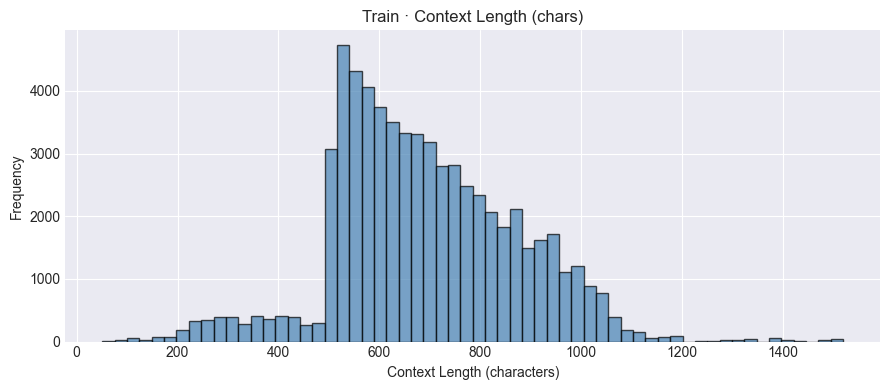


Validation Split:
  Total Examples: 7976
  Context Length (chars): Mean=667.424, Median=645
  Question Length (chars): Mean=56.122, Median=51
  Unanswerable (or no valid answer found): 1981


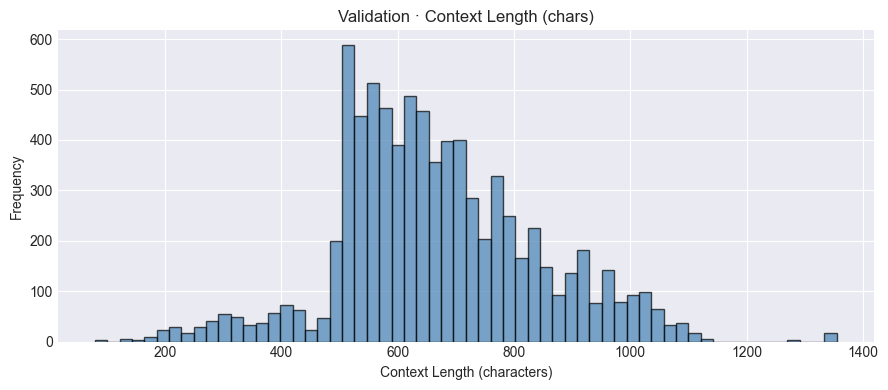


Test Split:
  Total Examples: 8002
  Context Length (chars): Mean=682.073, Median=653
  Question Length (chars): Mean=56.7894, Median=51
  Unanswerable (or no valid answer found): 1914


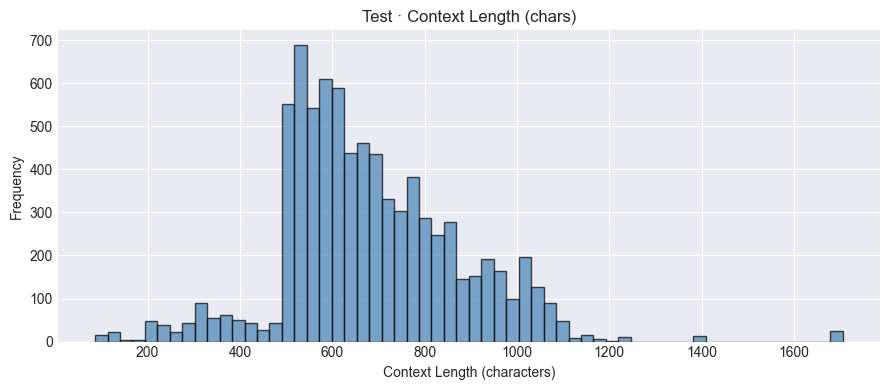

In [5]:
# ----- Pipeline:  load -> EDA -> train/eval ParsBERT and ALBERT-fa  -----
all_dataset_splits = load_pquad()

# Display normalization stats and examples
display_normalization(all_dataset_splits)

# Display QA pair examples
display_qa_pair_examples(all_dataset_splits)

# Map id -> original context (for post-proc char slicing)
global_contexts_map = {}
for split_data in all_dataset_splits.values():
    if not split_data["df"].empty: # Check if DataFrame is not empty
        for _, row in split_data["df"].iterrows():
            global_contexts_map[str(row.id)] = row.context # Ensure id is string key
print(f"\nCreated global context map with {len(global_contexts_map)} entries.")

# Quick stats + histograms
_ = Explorer(all_dataset_splits).analyse() # Output is a dict of stats, here assigned to _

In [6]:

# --- Function to run pipeline for a model ---
def run_pipeline_for_model(model_name: str):
    print(f"\n=== Pipeline for {model_name} ===")
    trainer = QATrainer(model_name, all_dataset_splits, global_contexts_map)
    trainer.train_model() # This now also plots history at the end
    
    print(f"\n--- {model_name} · Final TEST evaluation ---")
    # Load best model for final test evaluation
    best_model_path = os.path.join(CFG.OUT_DIR, model_name, "model_best.pt")
    print(f"Loading best model from {best_model_path} for final test evaluation...")
    trainer.load_checkpoint(best_model_path)

    
    test_scores = trainer.evaluate_model(trainer.dataloader_test, "TEST (Final)", CFG.EPOCHS)

    # Free GPU memory
    if CFG.DEVICE.type == "cuda":
        del trainer.model # Remove model from memory
        del trainer # Remove trainer
        torch.cuda.empty_cache()
        print(f"Cleared GPU cache after {model_name} run.")


=== Pipeline for ParsBERT ===

--- Initializing Trainer for: ParsBERT (HooshvareLab/bert-base-parsbert-uncased) ---


Map:   0%|          | 0/63994 [00:00<?, ? examples/s]

Map:   0%|          | 0/7976 [00:00<?, ? examples/s]

Map:   0%|          | 0/8002 [00:00<?, ? examples/s]

Tokenized datasets created for ParsBERT.
  Training features (post-windowing): 64729
  Validation features (post-windowing): 8009
  Test features (post-windowing): 8088

--- Starting Training: ParsBERT ---


...

ParsBERT · Epoch 2/2:   0%|          | 0/16182 [00:00<?, ?it/s]

Epoch 2 · Avg Train Loss = 5.861619e-01


Evaluating (VALIDATION):   0%|          | 0/251 [00:00<?, ?it/s]

Postprocessing:   0%|          | 0/7976 [00:00<?, ?it/s]

ParsBERT · Epoch 2 · VALIDATION — Loss=0 F1=63.6146 | EM=49.7367
New best validation F1: 63.6146! Saving model...
Checkpoint saved to ./qa_run\ParsBERT\model_best.pt
--- Training Finished for ParsBERT ---


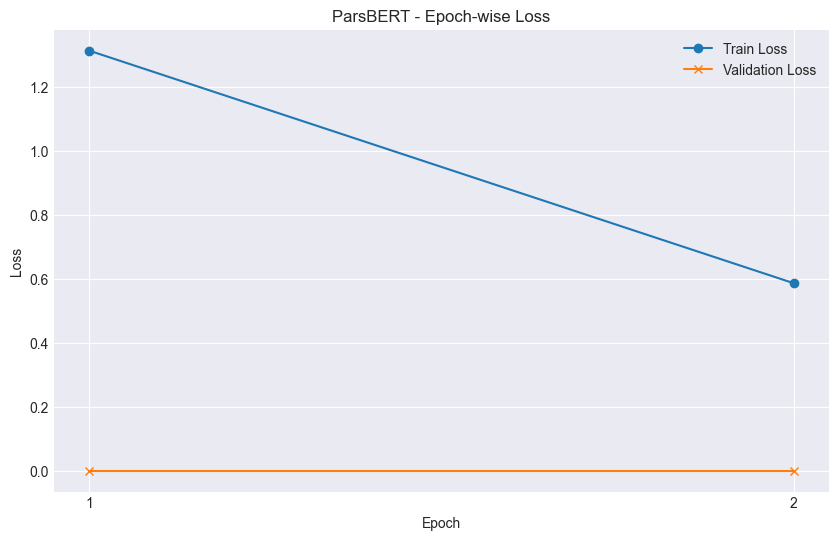

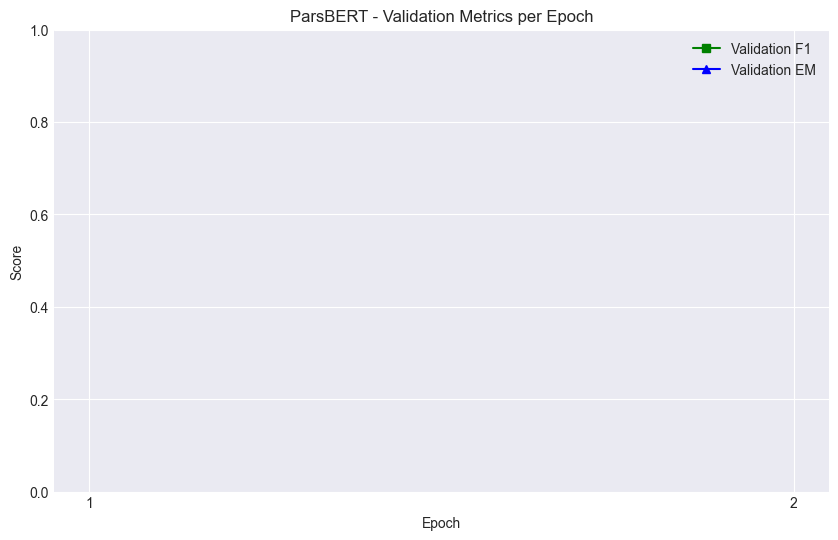

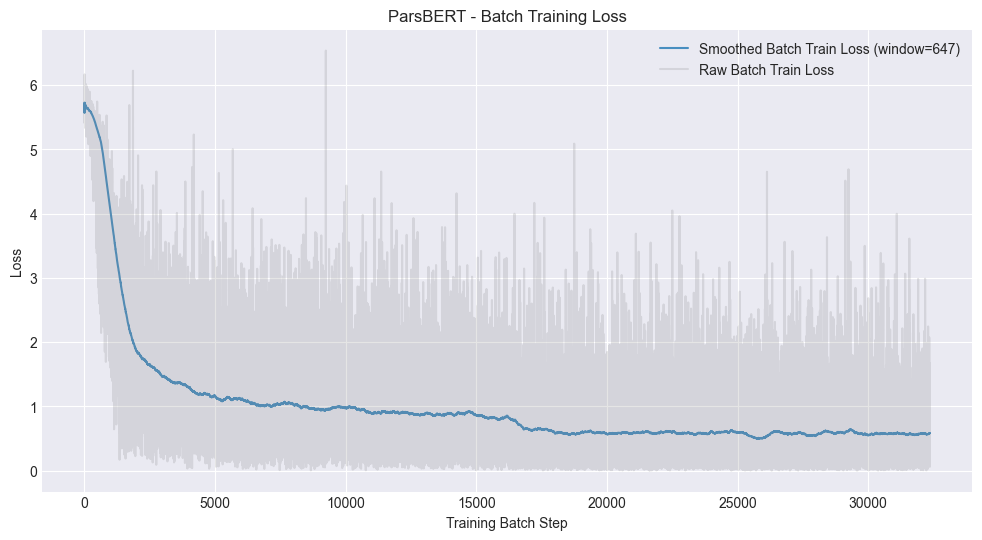


--- ParsBERT · Final TEST evaluation ---
Loading best model from ./qa_run\ParsBERT\model_best.pt for final test evaluation...
Checkpoint loaded from ./qa_run\ParsBERT\model_best.pt. Resuming from epoch 3.


Evaluating (TEST (Final)):   0%|          | 0/253 [00:00<?, ?it/s]

Postprocessing:   0%|          | 0/8002 [00:00<?, ?it/s]

ParsBERT · Epoch 2 · TEST (Final) — Loss=0 F1=65.5318 | EM=52.1495
Cleared GPU cache after ParsBERT run.


In [7]:
# --- Run for ParsBERT ---
run_pipeline_for_model("ParsBERT")


=== Pipeline for ALBERT ===

--- Initializing Trainer for: ALBERT (m3hrdadfi/albert-fa-base-v2) ---


Map:   0%|          | 0/63994 [00:00<?, ? examples/s]

Map:   0%|          | 0/7976 [00:00<?, ? examples/s]

Map:   0%|          | 0/8002 [00:00<?, ? examples/s]

Tokenized datasets created for ALBERT.
  Training features (post-windowing): 67073
  Validation features (post-windowing): 8267
  Test features (post-windowing): 8483

--- Starting Training: ALBERT ---


...

ALBERT · Epoch 2/2:   0%|          | 0/16768 [00:00<?, ?it/s]

Epoch 2 · Avg Train Loss = 5.887392e-01


Evaluating (VALIDATION):   0%|          | 0/259 [00:00<?, ?it/s]

Postprocessing:   0%|          | 0/7976 [00:00<?, ?it/s]

ALBERT · Epoch 2 · VALIDATION — Loss=0 F1=63.1265 | EM=52.6078
New best validation F1: 63.1265! Saving model...
Checkpoint saved to ./qa_run\ALBERT\model_best.pt
--- Training Finished for ALBERT ---


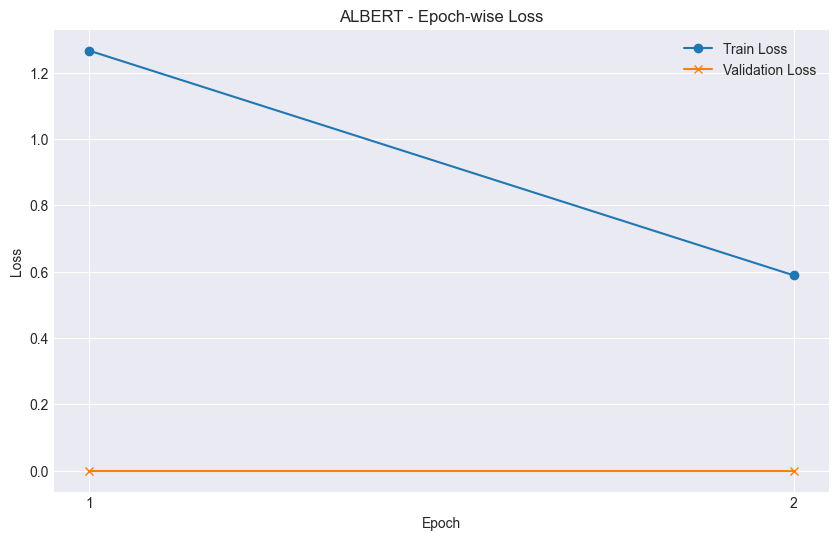

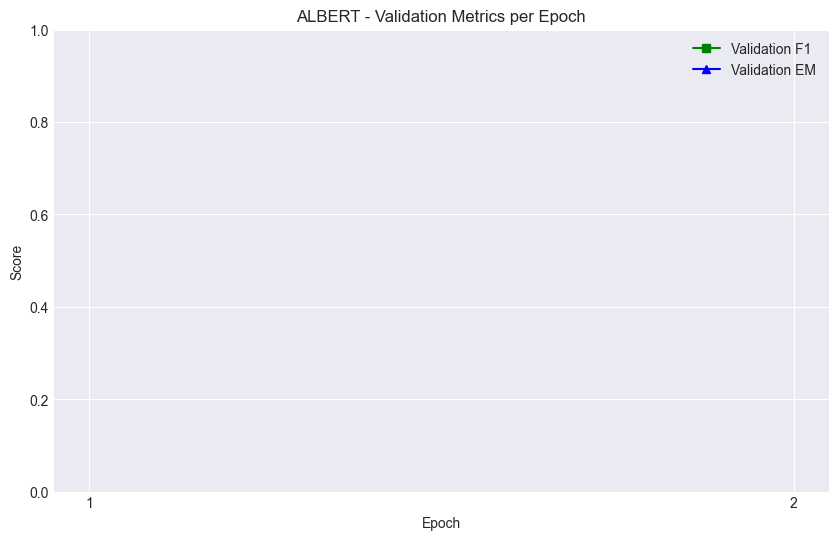

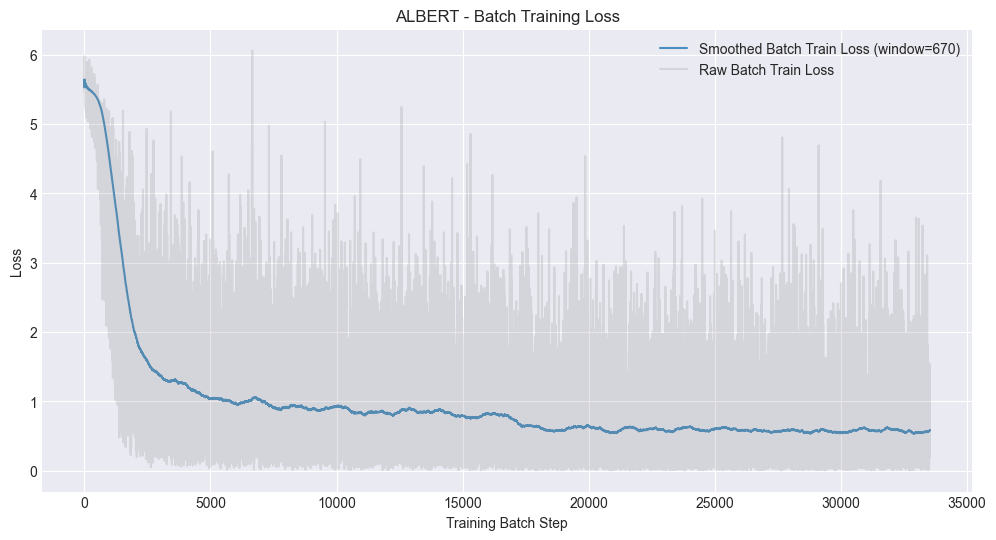


--- ALBERT · Final TEST evaluation ---
Loading best model from ./qa_run\ALBERT\model_best.pt for final test evaluation...
Checkpoint loaded from ./qa_run\ALBERT\model_best.pt. Resuming from epoch 3.


Evaluating (TEST (Final)):   0%|          | 0/266 [00:00<?, ?it/s]

Postprocessing:   0%|          | 0/8002 [00:00<?, ?it/s]

ALBERT · Epoch 2 · TEST (Final) — Loss=0 F1=64.9883 | EM=54.124
Cleared GPU cache after ALBERT run.


In [8]:
# --- Run for ALBERT-fa ---
run_pipeline_for_model("ALBERT")

#### Results Analysis

After training and evaluating both ALBERT and ParsBERT on the PQuAD dataset, we saw that the models performed quite closely overall, with **ParsBERT achieving a slightly higher F1 score on the test set (65.53%) compared to ALBERT (64.99%)**, while ALBERT had a slightly better Exact Match (EM) score (54.12% vs. 52.15%). This tells us that ALBERT was a bit more precise when it came to predicting exact spans, while ParsBERT had a better grasp of general answer overlap. These small differences likely reflect their architectural trade-offs: ALBERT, with its parameter sharing and lightweight structure, may generalize better in some cases, whereas ParsBERT benefits from having a fuller BERT backbone trained on Persian texts.

We can say that **both models maintained consistent performance across validation and test sets**, which is a good sign — it means the models are not overfitting and the preprocessing pipeline is working solid. On the other hand, we did notice that the EM scores were significantly lower than the F1 scores, which is common QA tasks. This suggests that the models are often "close" to the correct answer — giving spans that overlap a lot with the ground truth — but maybe off by a few characters, punctuation marks, or trailing words. Better postprocessing or answer span alignment could help close this gap.

Overall, while **neither model reaches the performance level of BERT on large English datasets like SQuAD (which can exceed 90% F1)**, these results are quite good for a Persian-language QA system trained on limited data. With some further tuning — maybe longer training or better span extraction — we may reach higher numbers.